<a href="https://colab.research.google.com/github/amal750/project/blob/main/CS.383.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [14]:
!pip install opencv-python matplotlib pillow numpy

In [15]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [16]:
!apt-get install -y p7zip-full

!7z x /content/archive.zip -o/content/dataset

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 243202317 bytes (232 MiB)

Extracting archive: /content/archive.zip
 34% 4096 Open              --
Path = /content/archive.zip
Type = zip
Physical Size = 243202317

  0%      5% 457 - train/images/000005_jpg.rf.30ace57dbc798585d1eb84720b55cfcc.jpg                                                                          

In [17]:
!ls /content/dataset

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [18]:
DATASET_PATH = "/content/dataset"

IMAGE_PATH = os.path.join(DATASET_PATH, "test/images")

images = glob.glob(os.path.join(IMAGE_PATH, "*.jpg"))

print("Total Images:", len(images))

for i, img in enumerate(images[:5]):
    print(f"[{i+1}] {img}")

Total Images: 100
[1] /content/dataset/test/images/000017_jpg.rf.80bdab72f33718f77521da4f48fbc667.jpg
[2] /content/dataset/test/images/000020_jpg.rf.9720d004d7d54ec9e9a316ea335bfd4d.jpg
[3] /content/dataset/test/images/000005_JPG_jpg.rf.3f58d06eaa6a58443139337347d5ffd8.jpg
[4] /content/dataset/test/images/000024_jpg.rf.df34892fd00bc4276c0dbe0ad8e16247.jpg
[5] /content/dataset/test/images/000017_jpg.rf.6264339ebbcbecc12e297e2a869b3db4.jpg


In [19]:
def load_image(image_path):

    img_bgr = cv2.imread(image_path)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    return img_bgr, img_rgb

In [20]:
def preprocess(img_bgr):

    # Convert to grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Resize image
    resized = cv2.resize(gray, (640, 640))

    return gray, resized

In [ ]:
def filtering(gray):

    # Gaussian Filter
    gaussian = cv2.GaussianBlur(gray, (5, 5), 0)

    # Median Filter
    median = cv2.medianBlur(gray, 5)

    # Bilateral Filter
    bilateral = cv2.bilateralFilter(gray, 9, 75, 75)

    return gaussian, median, bilateral

In [21]:
def edge_detection(filtered):

    # Canny Edge Detection
    canny = cv2.Canny(filtered, 100, 200)

    # Sobel Edge Detection
    sobelx = cv2.Sobel(filtered, cv2.CV_64F, 1, 0, ksize=5)

    sobely = cv2.Sobel(filtered, cv2.CV_64F, 0, 1, ksize=5)

    sobel = cv2.magnitude(sobelx, sobely)

    return canny, sobel

In [22]:
def segmentation(gray):

    # Binary Threshold
    _, thresh = cv2.threshold(
        gray,
        127,
        255,
        cv2.THRESH_BINARY
    )

    # Adaptive Threshold
    adaptive = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    return thresh, adaptive

In [23]:
def show_results(
    original,
    gray,
    gaussian,
    median,
    edges,
    thresh
):

    plt.figure(figsize=(15,10))

    # Original
    plt.subplot(2,3,1)
    plt.title("Original")
    plt.imshow(original)
    plt.axis("off")

    # Gray
    plt.subplot(2,3,2)
    plt.title("Gray")
    plt.imshow(gray, cmap='gray')
    plt.axis("off")

    # Gaussian
    plt.subplot(2,3,3)
    plt.title("Gaussian Filter")
    plt.imshow(gaussian, cmap='gray')
    plt.axis("off")

    # Median
    plt.subplot(2,3,4)
    plt.title("Median Filter")
    plt.imshow(median, cmap='gray')
    plt.axis("off")

    # Edges
    plt.subplot(2,3,5)
    plt.title("Canny Edge Detection")
    plt.imshow(edges, cmap='gray')
    plt.axis("off")

    # Segmentation
    plt.subplot(2,3,6)
    plt.title("Threshold Segmentation")
    plt.imshow(thresh, cmap='gray')
    plt.axis("off")

    plt.show()

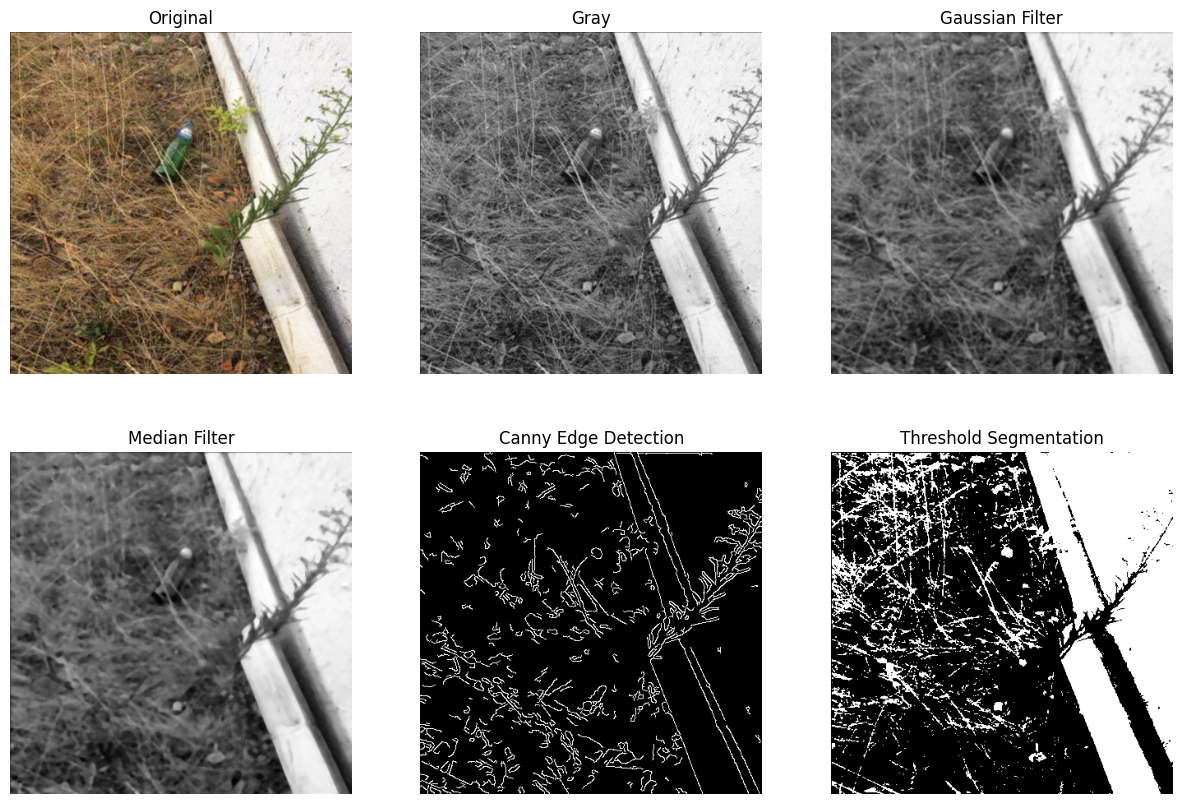

In [24]:
image_path = images[0]

# Load image
img_bgr, img_rgb = load_image(image_path)

# Preprocessing
gray, resized = preprocess(img_bgr)

# Filtering
gaussian, median, bilateral = filtering(gray)

# Edge Detection
edges, sobel = edge_detection(gaussian)

# Segmentation
thresh, adaptive = segmentation(gray)

# Show Results
show_results(
    img_rgb,
    gray,
    gaussian,
    median,
    edges,
    thresh
)